<a href="https://colab.research.google.com/github/Nishin-10/Nishin-10/blob/main/Assignment_1_RL_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install Gymnasium, Stable Baselines3, and plotting libraries
!pip install gymnasium[toy-text] stable-baselines3 shimmy matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 4.5 MB/s eta 0:00:00


=== Environment Details ===
Observation Space: Discrete(16)
Action Space: Discrete(4)
Description: Crossing a frozen lake (S->G). Slippery=True makes actions stochastic.

=== Random Agent Interaction ===


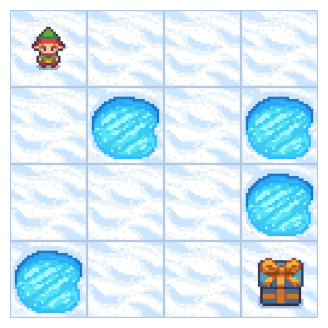

Step 1: Action taken: 0
Step 2: Action taken: 0
Step 3: Action taken: 3
Step 4: Action taken: 1
Step 5: Action taken: 0


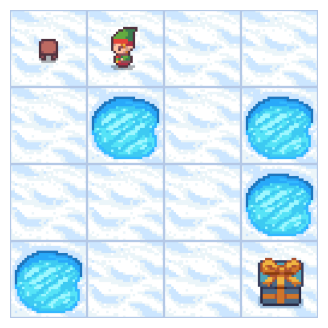

In [2]:
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython import display

def show_env(env):
    """Helper to render the environment in Colab"""
    plt.figure(figsize=(4, 4))
    plt.imshow(env.render()) # Render the RGB array
    plt.axis('off')
    plt.show()

# 1. Environment Selection
# We use render_mode="rgb_array" for Colab compatibility
env = gym.make('FrozenLake-v1', map_name="4x4", is_slippery=True, render_mode="rgb_array")

print("=== Environment Details ===")
print(f"Observation Space: {env.observation_space}")
print(f"Action Space: {env.action_space}")
print(f"Description: Crossing a frozen lake (S->G). Slippery=True makes actions stochastic.")

# 2. Run Random Episode
print("\n=== Random Agent Interaction ===")
obs, info = env.reset()
show_env(env) # Show start state

done = False
truncated = False
steps = 0

while not (done or truncated) and steps < 5: # Limit to 5 steps for demo
    action = env.action_space.sample()
    obs, reward, done, truncated, info = env.step(action)
    print(f"Step {steps+1}: Action taken: {action}")
    steps += 1

show_env(env) # Show state after a few steps
if done: print("Episode finished!")
env.close()

In [3]:
import os
import numpy as np
from stable_baselines3 import PPO, A2C, DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy

# Create a temporary directory for logs
log_dir = "/content/training_logs/"
os.makedirs(log_dir, exist_ok=True)

# Training configuration
TIMESTEPS = 100000  # High number needed for FrozenLake to learn
models_to_train = [
    {"name": "PPO", "class": PPO},
    {"name": "A2C", "class": A2C},
    {"name": "DQN", "class": DQN}
]

trained_models = {}

print("=== Starting Training (This may take 2-3 minutes) ===")

for model_info in models_to_train:
    algo_name = model_info["name"]
    algo_class = model_info["class"]

    # Create a separate log folder for each algorithm to avoid file overwrite conflicts
    algo_log_path = os.path.join(log_dir, algo_name)
    os.makedirs(algo_log_path, exist_ok=True)

    # Initialize env with Monitor wrapper
    # We create a new env for each model to ensure a clean start
    env = gym.make('FrozenLake-v1', map_name="4x4", is_slippery=True, render_mode="rgb_array")
    env = Monitor(env, algo_log_path)

    print(f"Training {algo_name}...")
    model = algo_class("MlpPolicy", env, verbose=0)
    model.learn(total_timesteps=TIMESTEPS)
    model.save(f"{algo_name}_frozenlake")
    trained_models[algo_name] = model
    env.close()

print("All models trained!")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


=== Starting Training (This may take 2-3 minutes) ===
Training PPO...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Training A2C...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Training DQN...
All models trained!


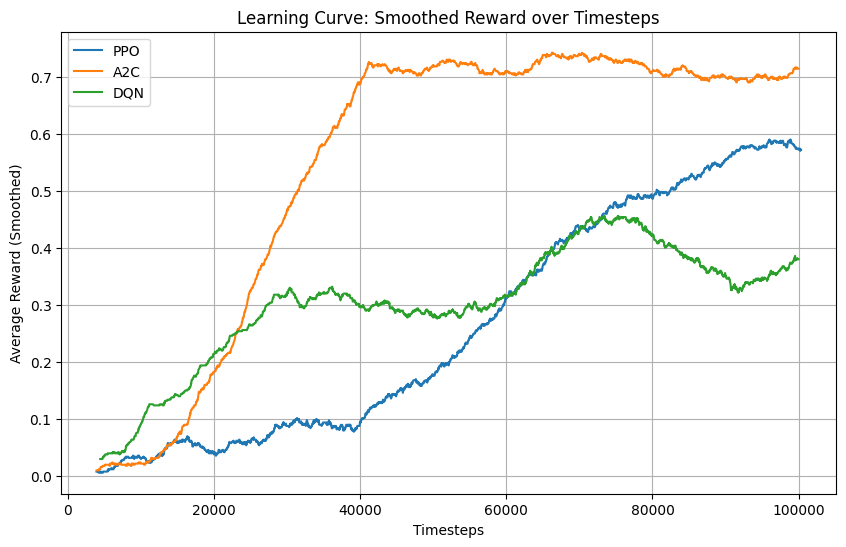

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



=== Final Performance Summary ===
  Algorithm  Final Avg Reward
0       PPO              0.46
1       A2C              0.73
2       DQN              0.44


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


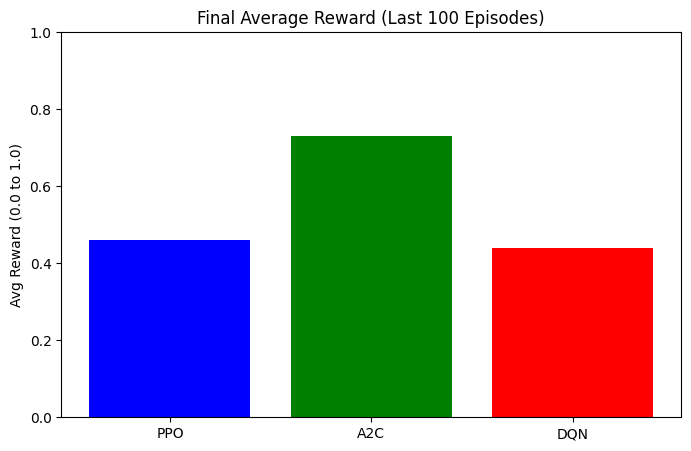

In [4]:
import pandas as pd

# Helper function to get moving average
def moving_average(values, window):
    return np.convolve(values, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 6))

final_results = []

# --- 1. Plot Learning Curves ---
for model_info in models_to_train:
    name = model_info["name"]
    folder = os.path.join(log_dir, name)

    # Load log data (x = timesteps, y = episode reward)
    x, y = ts2xy(load_results(folder), 'timesteps')

    # Calculate Average Reward (Smooth the curve)
    if len(y) > 0:
        mean_reward = np.mean(y[-100:]) # Last 100 episodes
        final_results.append({"Algorithm": name, "Final Avg Reward": mean_reward})

        # Plot smoothed curve
        y_smoothed = moving_average(y, window=500)
        x_smoothed = x[len(x) - len(y_smoothed):]
        plt.plot(x_smoothed, y_smoothed, label=name)

plt.title("Learning Curve: Smoothed Reward over Timesteps")
plt.xlabel("Timesteps")
plt.ylabel("Average Reward (Smoothed)")
plt.legend()
plt.grid(True)
plt.show()

# --- 2. Plot Summary Bar Chart ---
df = pd.DataFrame(final_results)
print("\n=== Final Performance Summary ===")
print(df)

plt.figure(figsize=(8, 5))
plt.bar(df["Algorithm"], df["Final Avg Reward"], color=['blue', 'green', 'red'])
plt.title("Final Average Reward (Last 100 Episodes)")
plt.ylabel("Avg Reward (0.0 to 1.0)")
plt.ylim(0, 1.0) # Max reward is 1.0
plt.show()

In [8]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from IPython.display import display, Video
import glob

# 1. Setup the Recording Environment
video_folder = "frozenlake_videos"
# We use render_mode="rgb_array" to capture frames without a window
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True, render_mode="rgb_array")

# Wrap the env to record video
# episode_trigger = lambda x: True  --> Records every episode we run
env = RecordVideo(env, video_folder=video_folder, episode_trigger=lambda x: True, name_prefix="best_agent")

# 2. Select your best model
# (Assuming 'trained_models' dictionary from Cell 3 exists)
# We usually use PPO or DQN as the best candidate.
best_model = trained_models["A2C"] # Changed from PPO to A2C for better performance

print("=== Recording Video ===")

# 3. Run Episodes
# We run 5 episodes because the lake is slippery; we want to capture at least one success!
episodes_to_record = 5

for i in range(episodes_to_record):
    obs, info = env.reset()
    done = False
    truncated = False

    while not (done or truncated):
        # deterministic=True tells the agent to use its BEST move, not explore random ones
        action, _ = best_model.predict(obs, deterministic=True)
        # Convert the action (which might be a numpy array) to a scalar integer
        obs, reward, done, truncated, info = env.step(action.item())

    outcome = "Success" if reward == 1.0 else "Fell in hole"
    print(f"Episode {i+1} finished: {outcome}")

env.close()

# 4. Display the Video in Colab
mp4list = glob.glob(f'{video_folder}/*.mp4')
if len(mp4list) > 0:
    print(f"\nDisplaying video: {mp4list[0]}")
    # Show the last recorded video
    display(Video(mp4list[0], embed=True, html_attributes="controls loop autoplay"))
else:
    print("No video found.")

print(f"\nTo download the video, look in the folder '{video_folder}' in the Files tab on the left.")

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/frozenlake_videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


=== Recording Video ===
Episode 1 finished: Success
Episode 2 finished: Success
Episode 3 finished: Fell in hole
Episode 4 finished: Fell in hole
Episode 5 finished: Success

Displaying video: frozenlake_videos/best_agent-episode-1.mp4



To download the video, look in the folder 'frozenlake_videos' in the Files tab on the left.


In [9]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from IPython.display import Video
import glob
import os
import numpy as np

# 1. Configuration
video_folder = "frozenlake_success"
# Clean up previous videos if any
os.system(f"rm -rf {video_folder}")

# 2. Setup Environment with Video Recording
# We record EVERY episode so we don't miss the winning one
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True, render_mode="rgb_array")
env = RecordVideo(env, video_folder=video_folder, episode_trigger=lambda x: True, name_prefix="attempt")

# 3. Select Best Model (A2C)
best_model = trained_models["A2C"]

print("=== Hunting for a Success (Max 20 attempts) ===")

success_video_file = None

# Try up to 20 times to get a win
for episode in range(20):
    obs, info = env.reset()
    done = False
    truncated = False
    total_reward = 0

    while not (done or truncated):
        # Predict action
        action, _ = best_model.predict(obs, deterministic=True)
        action = int(action) # Fix for the TypeError

        obs, reward, done, truncated, info = env.step(action)
        total_reward += reward

    # If we won (Reward = 1.0), save this video and STOP
    if total_reward == 1.0:
        print(f"🎉 SUCCESS! The agent reached the goal in Episode {episode}.")
        env.close() # Close to save the file

        # The filename format is usually "name_prefix-episode-X.mp4"
        success_video_file = f"{video_folder}/attempt-episode-{episode}.mp4"
        break
    else:
        print(f"Episode {episode}: Failed (Fell in hole). Retrying...")

env.close()

# 4. Display the Winning Video
if success_video_file and os.path.exists(success_video_file):
    print(f"\nDisplaying Winning Video: {success_video_file}")
    display(Video(success_video_file, embed=True, html_attributes="controls loop autoplay"))
else:
    print("\n⚠️ Unlucky! The agent failed 20 times in a row. Try running this cell again.")

=== Hunting for a Success (Max 20 attempts) ===
🎉 SUCCESS! The agent reached the goal in Episode 0.

Displaying Winning Video: frozenlake_success/attempt-episode-0.mp4
